In [1]:
# Importing all the required Python libraries 

import pandas as pd
import numpy as np
import math 
import matplotlib.pyplot as plt
from random import randint
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn import linear_model
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

In [2]:

# Reading the data from the CSV dataset file
dataFrame = pd.read_csv('CRC_SEER_Modified.csv')
print(dataFrame)


       Year of diagnosis Race recode (W, B, AI, API)     Sex  \
0                   2000                       White    Male   
1                   2000                       White    Male   
2                   2000                       White  Female   
3                   2000                       White    Male   
4                   2000                       White  Female   
...                  ...                         ...     ...   
29996               2016                       White  Female   
29997               2016                       White  Female   
29998               2016                       White  Female   
29999               2016                       White  Female   
30000               2016   Asian or Pacific Islander    Male   

      Age recode with single ages and 100+ Survival months  \
0                                 82 years              17   
1                                 76 years              67   
2                                 65 years   

In [3]:

dataFrame.rename(columns={'Year of diagnosis': 'Year', # Changing the Name of the Column from Year of diagnosis to Years
                            'Race recode (W, B, AI, API)': 'Race', # Changing the Name of the Column from Race recode (W, B, AI, API) to Race
                            'Age recode with single ages and 100+': 'Age', # Changing the Name of the Column from Age recode with single ages and 100+ to Age
                            'Survival months': 'SurvivalMonths', # Changing the Name of the Column from Survival months to SurvivalMonths
                            'Marital status at diagnosis': 'MaritalStatus', # Changing the Name of the Column from Marital status at diagnosis to MaritalStatus 
                            'target': 'SurvivalRecode'}, # Changing the Name of the Column from target and 100+ to SurvivalRecode
                   inplace=True)

dataFrame['Race'] = dataFrame['Race'].map({  # Changing the Race column values to numeric values
    'White': 1,
    'Black': 2,
    'Asian or Pacific Islander': 3,
    'American Indian/Alaskan Native': 4,
    'Hispanic': 5,
    'Blank': 6
})
dataFrame.replace('Unknown', np.nan, inplace=True) # Replace 'Unknown' with NaN
dataFrame['Sex'] = dataFrame['Sex'].map({'Male': 1,'Female': 0}) # Changing the Sex Column values to Boolean values
dataFrame['Age'] = dataFrame['Age'].str.replace(' years','') # Removing the "years" sting from age column 
dataFrame['Age'] = pd.to_numeric(dataFrame['Age'], errors='coerce') # converting the Age column values to numeric values for better results and to perform mathematical comparisons
dataFrame.loc[dataFrame['Age'] >= 100, 'Age'] = 101

dataFrame['MaritalStatus'] = dataFrame['MaritalStatus'].map({  # Changing the MaritalStatus column values to numeric values 
    'Married (including common law)': 1,
    'Single (never married)': 2,
    'Divorced': 3,
    'Widowed': 4,
    'Unknown': 5})

print(dataFrame)

       Year  Race  Sex   Age SurvivalMonths  MaritalStatus  SurvivalRecode
0      2000   1.0    1  82.0             17            1.0               1
1      2000   1.0    1  76.0             67            NaN               1
2      2000   1.0    0  65.0             41            NaN               1
3      2000   1.0    1  86.0             15            NaN               1
4      2000   1.0    0  82.0              0            NaN               1
...     ...   ...  ...   ...            ...            ...             ...
29996  2016   1.0    0  73.0             28            1.0               0
29997  2016   1.0    0  63.0             28            1.0               0
29998  2016   1.0    0  82.0             28            2.0               0
29999  2016   1.0    0  44.0             29            1.0               0
30000  2016   3.0    1  52.0             29            1.0               0

[30001 rows x 7 columns]


In [4]:
crc_seer_recoded_df = dataFrame.copy() # Renaming the data frame name from "dataFrame" to "crc_seer_recoded_df"
print(crc_seer_recoded_df)

       Year  Race  Sex   Age SurvivalMonths  MaritalStatus  SurvivalRecode
0      2000   1.0    1  82.0             17            1.0               1
1      2000   1.0    1  76.0             67            NaN               1
2      2000   1.0    0  65.0             41            NaN               1
3      2000   1.0    1  86.0             15            NaN               1
4      2000   1.0    0  82.0              0            NaN               1
...     ...   ...  ...   ...            ...            ...             ...
29996  2016   1.0    0  73.0             28            1.0               0
29997  2016   1.0    0  63.0             28            1.0               0
29998  2016   1.0    0  82.0             28            2.0               0
29999  2016   1.0    0  44.0             29            1.0               0
30000  2016   3.0    1  52.0             29            1.0               0

[30001 rows x 7 columns]


In [5]:
# Set the seed for random number generation to ensure reproducibility
np.random.seed(42)

# Create feature vector X by selecting all columns except the 'SurvivalRecode' column from the DataFrame
X = crc_seer_recoded_df.loc[:, crc_seer_recoded_df.columns != 'SurvivalRecode']

# Create target vector y by selecting only the 'SurvivalRecode' column from the DataFrame
y = crc_seer_recoded_df['SurvivalRecode']

# Split the data into training and testing sets
# 80% of the data will be used for training (X_train, y_train) and 20% for testing (X_test, y_test)
# The random_state parameter ensures that the split is reproducible
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(crc_seer_recoded_df)

       Year  Race  Sex   Age SurvivalMonths  MaritalStatus  SurvivalRecode
0      2000   1.0    1  82.0             17            1.0               1
1      2000   1.0    1  76.0             67            NaN               1
2      2000   1.0    0  65.0             41            NaN               1
3      2000   1.0    1  86.0             15            NaN               1
4      2000   1.0    0  82.0              0            NaN               1
...     ...   ...  ...   ...            ...            ...             ...
29996  2016   1.0    0  73.0             28            1.0               0
29997  2016   1.0    0  63.0             28            1.0               0
29998  2016   1.0    0  82.0             28            2.0               0
29999  2016   1.0    0  44.0             29            1.0               0
30000  2016   3.0    1  52.0             29            1.0               0

[30001 rows x 7 columns]


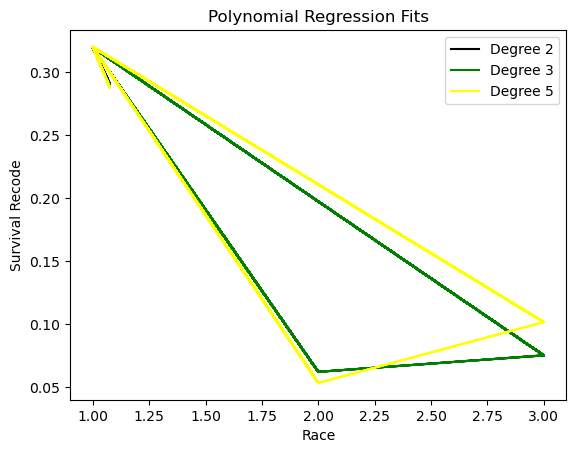

Best polynomial degree: 3 with RMSE: 0.45684471781300284


In [6]:
# Create an instance of SimpleImputer with the strategy set to 'mean'
imputer = SimpleImputer(strategy='mean')

# Impute missing values in the 'Race' column of the training set
X_train_imputed = imputer.fit_transform(X_train[['Race']])

# Impute missing values in the 'Race' column of the testing set (without fitting the imputer again)
X_test_imputed = imputer.transform(X_test[['Race']])

# Define a list of polynomial degrees to evaluate
degrees = [2, 3, 5]

# Initialize an empty list to store RMSE values for each polynomial degree
rmse_values = []

# Define a list of colors for the plot
colors = ['black', 'green', 'yellow']  # Customizable list of colors

# Loop through each degree in the degrees list
for i, degree in enumerate(degrees):
    # Create an instance of PolynomialFeatures for the current degree
    poly = PolynomialFeatures(degree)
    
    # Transform the imputed training data into polynomial features
    X_poly = poly.fit_transform(X_train_imputed)
    
    # Create a linear regression model
    model = LinearRegression()
    
    # Fit the model using the polynomial features of the training data and the target variable
    model.fit(X_poly, y_train)
    
    # Predict the target variable using the polynomial features of the test set
    y_pred = model.predict(poly.transform(X_test_imputed))
    
    # Calculate the Root Mean Squared Error (RMSE) between the actual and predicted values
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    # Append the RMSE value to the list
    rmse_values.append(rmse)
    
    # Plot the predicted values against the test set imputed data for the current polynomial degree
    plt.plot(X_test_imputed, y_pred, label=f'Degree {degree}', color=colors[i])

# Label the x-axis and y-axis of the plot
plt.xlabel('Race')
plt.ylabel('Survival Recode')

# Set the title of the plot
plt.title('Polynomial Regression Fits')

# Show the legend for the plot
plt.legend()

# Display the plot
plt.show()

# Identify the degree of the polynomial that resulted in the lowest RMSE value
best_degree = degrees[np.argmin(rmse_values)]

# Print the best polynomial degree and its corresponding RMSE
print(f'Best polynomial degree: {best_degree} with RMSE: {min(rmse_values)}')


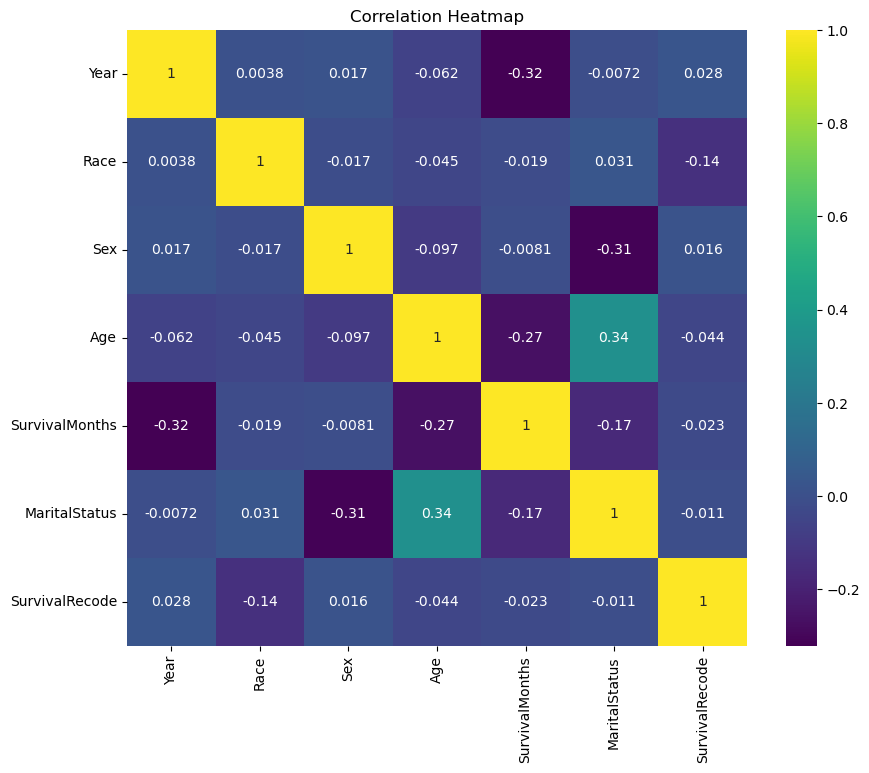

SurvivalRecode    1.000000
Year              0.027798
Sex               0.016024
MaritalStatus    -0.011407
SurvivalMonths   -0.023238
Age              -0.044209
Race             -0.138119
Name: SurvivalRecode, dtype: float64


In [7]:
# Compute the correlation matrix for the DataFrame
corr_matrix = crc_seer_recoded_df.corr()

# Set the figure size for the plot (width, height in inches)
plt.figure(figsize=(10, 8))

# Plot a heatmap of the correlation matrix using seaborn
# Change the cmap to 'viridis' for a different color scheme
sns.heatmap(corr_matrix, annot=True, cmap='viridis')

# Set the title of the heatmap
plt.title('Correlation Heatmap')

# Display the heatmap
plt.show()

# List features in decreasing order of their correlation impact on 'SurvivalRecode'
impact_features = corr_matrix['SurvivalRecode'].sort_values(ascending=False)

# Print the sorted list of features and their correlation values with 'SurvivalRecode'
print(impact_features)


In [8]:
# Create an imputer object to replace NaN values with the mean
imputer = SimpleImputer(strategy='mean')

# Fit the imputer on the training data and transform both train and test sets
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Train the logistic regression model
log_reg = LogisticRegression(max_iter=10000)
log_reg.fit(X_train_imputed, y_train)

# Predict on the test set
y_pred_log = log_reg.predict(X_test_imputed)

# Evaluate the model with zero_division parameter
print(classification_report(y_test, y_pred_log, zero_division=0))

              precision    recall  f1-score   support

           0       0.70      1.00      0.82      4173
           1       0.00      0.00      0.00      1828

    accuracy                           0.70      6001
   macro avg       0.35      0.50      0.41      6001
weighted avg       0.48      0.70      0.57      6001



In [9]:
# After comparing polynomial and logistic regression models, the following observations were made:
# Polynomial Regression: The best-fit polynomial regression model provided insights into the nonlinear relationship between race and survival.
 #Logistic Regression: Logistic regression models, particularly with the liblinear solver, provided robust predictions with interpretable coefficients.
 # Preferred Model: Logistic regression was preferred for this dataset due to its ability to handle binary outcomes effectively and provide interpretable results. The confusion matrix further validated the model's accuracy and precision.
